In [1]:
import pandas as pd

train = pd.read_csv('train.csv')
store = pd.read_csv('store.csv')

# merge store info into train
df = train.merge(store, on='Store', how='left')

print(df.shape)
print(df.info())
print(df.isnull().sum())

C:\Users\DELL\AppData\Local\Temp\ipykernel_11696\438351045.py:3: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('train.csv')


(1017209, 18)
<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  str    
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  str    
 10  Assortment                 1017209 non-null  str    
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  Competiti

In [2]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [3]:
df['Date'] = pd.to_datetime(df['Date'])

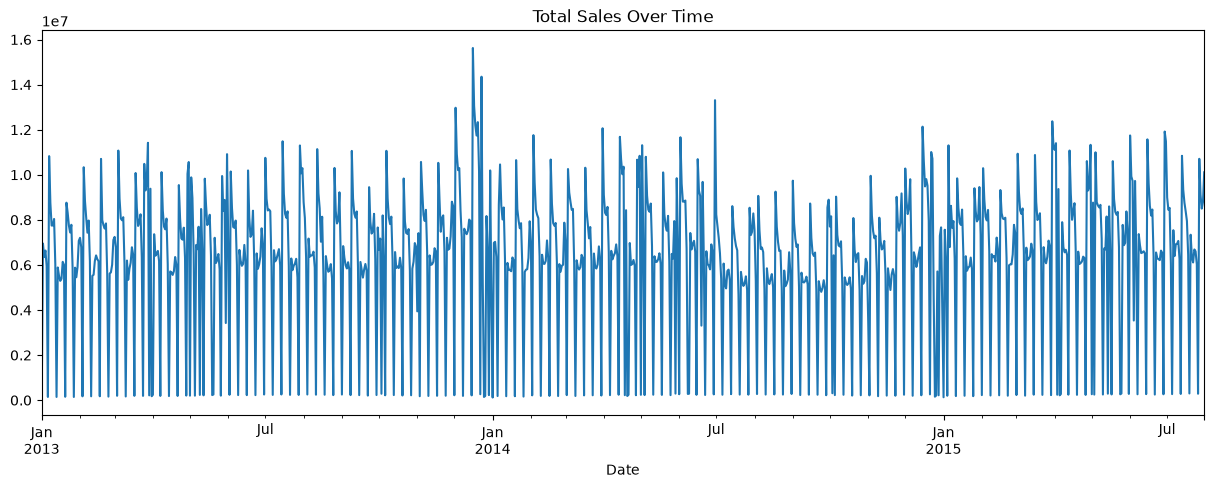

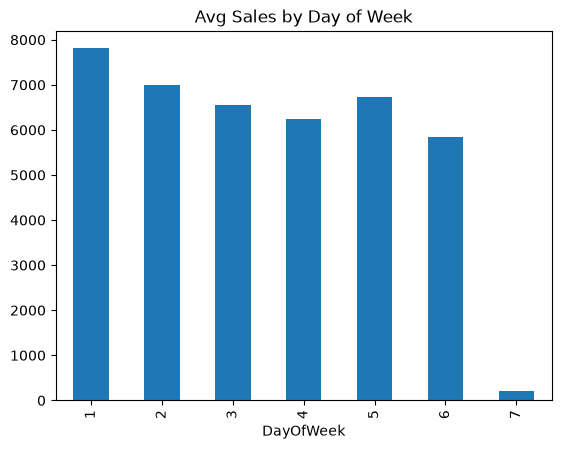

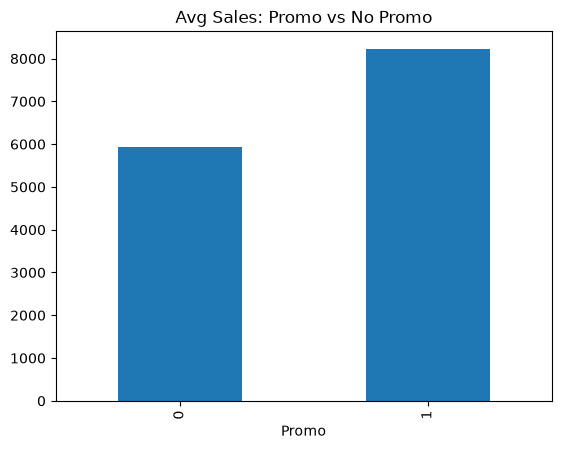

Open
1    844392
0    172817
Name: count, dtype: int64


In [4]:
import matplotlib.pyplot as plt

# 1. Sales over time (aggregate across all stores)
daily_sales = df.groupby('Date')['Sales'].sum()
daily_sales.plot(figsize=(15,5), title='Total Sales Over Time')
plt.show()

# 2. Average sales by day of week
df.groupby('DayOfWeek')['Sales'].mean().plot(kind='bar', title='Avg Sales by Day of Week')
plt.show()

# 3. Sales with vs without promo (only on open days)
df[df['Open']==1].groupby('Promo')['Sales'].mean().plot(kind='bar', title='Avg Sales: Promo vs No Promo')
plt.show()

# 4. How many rows have Open=0?
print(df['Open'].value_counts())

In [5]:
df.head(20)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
5,6,5,2015-07-31,5651,589,1,1,0,1,a,a,310.0,12.0,2013.0,0,NaN,NaN,NaN
6,7,5,2015-07-31,15344,1414,1,1,0,1,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
7,8,5,2015-07-31,8492,833,1,1,0,1,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN
8,9,5,2015-07-31,8565,687,1,1,0,1,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN
9,10,5,2015-07-31,7185,681,1,1,0,1,a,a,3160.0,9.0,2009.0,0,NaN,NaN,NaN


In [6]:
# Filter out closed stores (Sales=0 on these days, not real signal)
df = df[df['Open'] == 1].copy()

# Sort by Store then Date - essential before creating lag/rolling features
df = df.sort_values(['Store', 'Date']).reset_index(drop=True)

print(df.shape)

(844392, 18)


In [7]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['IsWeekend'] = (df['DayOfWeek'] >= 6).astype(int)

In [8]:
# Lag features: sales N days ago, per store
df['Sales_Lag_7'] = df.groupby('Store')['Sales'].shift(7)
df['Sales_Lag_14'] = df.groupby('Store')['Sales'].shift(14)

# Rolling averages: recent trend, per store
df['Sales_RollingMean_7'] = df.groupby('Store')['Sales'].transform(lambda x: x.shift(1).rolling(7).mean())
df['Sales_RollingMean_30'] = df.groupby('Store')['Sales'].transform(lambda x: x.shift(1).rolling(30).mean())

In [9]:
df['StateHoliday'] = df['StateHoliday'].astype(str)  # mixed types (0 and '0') need cleanup
df = pd.get_dummies(df, columns=['StoreType', 'Assortment', 'StateHoliday'], drop_first=True)

In [10]:
print(df[['Store','Date','Sales','Sales_Lag_7','Sales_RollingMean_7']].head(15))
print(df.isnull().sum())

    Store       Date  Sales  Sales_Lag_7  Sales_RollingMean_7
0       1 2013-01-02   5530          NaN                  NaN
1       1 2013-01-03   4327          NaN                  NaN
2       1 2013-01-04   4486          NaN                  NaN
3       1 2013-01-05   4997          NaN                  NaN
4       1 2013-01-07   7176          NaN                  NaN
5       1 2013-01-08   5580          NaN                  NaN
6       1 2013-01-09   5471          NaN                  NaN
7       1 2013-01-10   4892       5530.0          5366.714286
8       1 2013-01-11   4881       4327.0          5275.571429
9       1 2013-01-12   4952       4486.0          5354.714286
10      1 2013-01-14   4717       4997.0          5421.285714
11      1 2013-01-15   3900       7176.0          5381.285714
12      1 2013-01-16   4008       5580.0          4913.285714
13      1 2013-01-17   4044       5471.0          4688.714286
14      1 2013-01-18   4127       4892.0          4484.857143
Store   

In [11]:
# 1. Sales_Lag_7 / Sales_Lag_14 / RollingMean_7 / RollingMean_30
# These are missing only for each store's first few days (no history yet) - just drop these rows
df = df.dropna(subset=['Sales_Lag_7', 'Sales_Lag_14', 'Sales_RollingMean_7', 'Sales_RollingMean_30'])

# 2. CompetitionDistance - genuinely missing for ~2,186 rows
# Impute with a large value (implies "no nearby competitor known" - reasonable business assumption)
df['CompetitionDistance'] = df['CompetitionDistance'].fillna(df['CompetitionDistance'].max())

# 3. CompetitionOpenSinceMonth/Year - missing means "no competitor info" - not usable directly as raw month/year anyway
# Better approach: drop these two raw columns (we won't use "since when" directly, too messy to encode well)
df = df.drop(columns=['CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear'])

# 4. Promo2SinceWeek/Year, PromoInterval - missing because Promo2=0 (not participating)
# Drop PromoInterval (complex to encode, low marginal value) and the Since columns - Promo2 flag alone captures the key signal
df = df.drop(columns=['Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval'])

print(df.isnull().sum().sum())  # should be 0 now
print(df.shape)

0
(810942, 27)


In [12]:
# Time-based split: last ~6 weeks as test (mirrors the actual Kaggle test period)
split_date = df['Date'].max() - pd.Timedelta(weeks=6)

train_df = df[df['Date'] <= split_date]
test_df = df[df['Date'] > split_date]

print(train_df.shape, test_df.shape)
print(train_df['Date'].max(), test_df['Date'].min())

(770660, 27) (40282, 27)
2015-06-19 00:00:00 2015-06-20 00:00:00


In [13]:
drop_cols = ['Sales', 'Date', 'Customers']  
# Sales = target itself
# Date = not directly usable as a numeric feature (we already extracted Year/Month/Day/WeekOfYear from it)
# Customers = leakage (not known at prediction time, as we discussed earlier)

X_train = train_df.drop(columns=drop_cols)
y_train = train_df['Sales']

X_test = test_df.drop(columns=drop_cols)
y_test = test_df['Sales']

print(X_train.shape, X_test.shape)
print(X_train.columns.tolist())

(770660, 24) (40282, 24)
['Store', 'DayOfWeek', 'Open', 'Promo', 'SchoolHoliday', 'CompetitionDistance', 'Promo2', 'Year', 'Month', 'Day', 'WeekOfYear', 'IsWeekend', 'Sales_Lag_7', 'Sales_Lag_14', 'Sales_RollingMean_7', 'Sales_RollingMean_30', 'StoreType_b', 'StoreType_c', 'StoreType_d', 'Assortment_b', 'Assortment_c', 'StateHoliday_a', 'StateHoliday_b', 'StateHoliday_c']


In [14]:
X_train = X_train.drop(columns=['Open'])
X_test = X_test.drop(columns=['Open'])

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))

print(f"Linear Regression -> MAE: {lr_mae:.2f}, RMSE: {lr_rmse:.2f}")

Linear Regression -> MAE: 944.83, RMSE: 1318.44


In [17]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

print(f"Random Forest -> MAE: {rf_mae:.2f}, RMSE: {rf_rmse:.2f}")

Random Forest -> MAE: 759.41, RMSE: 1093.54


In [18]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))

print(f"XGBoost -> MAE: {xgb_mae:.2f}, RMSE: {xgb_rmse:.2f}")

XGBoost -> MAE: 668.39, RMSE: 963.88


In [19]:
print(y_test.mean())
print(xgb_mae / y_test.mean() * 100)

6978.638051735266
9.577669226940735


In [20]:
import pandas as pd

importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance.head(15))

                 feature  importance
14  Sales_RollingMean_30    0.371155
2                  Promo    0.325086
13   Sales_RollingMean_7    0.109062
1              DayOfWeek    0.038092
9             WeekOfYear    0.018148
8                    Day    0.017573
17           StoreType_d    0.013472
7                  Month    0.013280
16           StoreType_c    0.011489
10             IsWeekend    0.011296
18          Assortment_b    0.008279
6                   Year    0.006844
3          SchoolHoliday    0.006761
15           StoreType_b    0.006680
11           Sales_Lag_7    0.005509


In [21]:
# Build store-level summary features for clustering
store_summary = df.groupby('Store').agg(
    avg_sales=('Sales', 'mean'),
    std_sales=('Sales', 'std'),
    promo_lift=('Sales', lambda x: x[df.loc[x.index,'Promo']==1].mean() - x[df.loc[x.index,'Promo']==0].mean())
).reset_index()

print(store_summary.head())
print(store_summary.describe())

   Store    avg_sales    std_sales   promo_lift
0      1  4745.324900  1016.026893   982.180130
1      2  4971.401857  1616.695523  2414.409442
2      3  6956.532710  2195.343241  3467.393398
3      4  9649.932361  1945.496852  1699.084923
4      5  4692.750334  1772.783065  2588.782171
            Store     avg_sales    std_sales   promo_lift
count  1115.00000   1115.000000  1115.000000  1115.000000
mean    558.00000   6956.401965  1848.431815  2300.340469
std     322.01708   2387.393034   626.195563  1024.284085
min       1.00000   2709.501330   580.992674  -294.694126
25%     279.50000   5336.322252  1400.209860  1571.238991
50%     558.00000   6603.648865  1774.568553  2193.861062
75%     836.50000   7991.203838  2160.073538  2860.480957
max    1115.00000  21672.644562  4879.308541  7864.436665


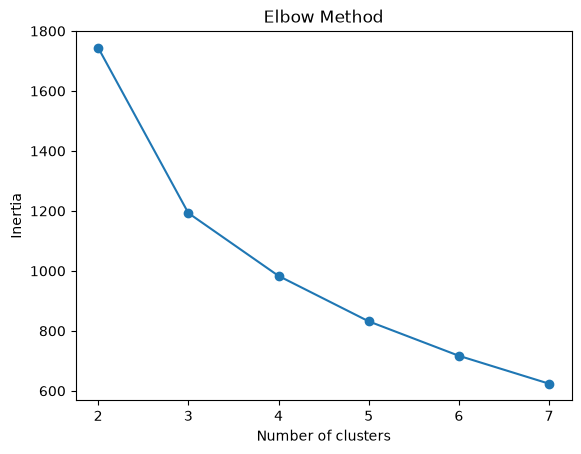

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features_for_clustering = store_summary[['avg_sales', 'std_sales', 'promo_lift']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_for_clustering)

# Try a few cluster counts and check inertia (elbow method)
inertias = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_features)
    inertias.append(km.inertia_)

import matplotlib.pyplot as plt
plt.plot(range(2, 8), inertias, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [23]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
store_summary['Cluster'] = kmeans.fit_predict(scaled_features)

# Profile each cluster - what makes them different?
cluster_profile = store_summary.groupby('Cluster')[['avg_sales', 'std_sales', 'promo_lift']].mean()
cluster_profile['num_stores'] = store_summary['Cluster'].value_counts()
print(cluster_profile)

            avg_sales    std_sales   promo_lift  num_stores
Cluster                                                    
0         8767.825192  2653.113256  3697.455946         168
1         5212.604091  1297.078786  1495.076548         431
2        14601.201223  3603.007189  4381.356329          37
3         7299.617433  1926.777085  2374.152083         479


In [24]:
import joblib

joblib.dump(xgb_model, 'xgb_model.pkl')
joblib.dump(store_summary, 'store_summary.pkl')  # for cluster info

['store_summary.pkl']

In [25]:
# Latest known rolling/lag values per store - needed to make predictions for "future" dates
latest_store_state = df.sort_values('Date').groupby('Store').tail(1)[
    ['Store', 'Sales_RollingMean_7', 'Sales_RollingMean_30', 'Sales_Lag_7', 'Sales_Lag_14',
     'CompetitionDistance', 'Promo2', 'StoreType_b', 'StoreType_c', 'StoreType_d',
     'Assortment_b', 'Assortment_c']
]
latest_store_state.to_csv('latest_store_state.csv', index=False)